# LLM-as-judge (local Ollama) — BriefMe heading quality

This notebook **evaluates** candidate section headings with a **frozen rubric** in [`briefme.judge_ollama`](../src/briefme/judge_ollama.py). It includes a **gold-heading sanity** check on a Hub subset, then **scratch seq2seq** predictions **loaded** from **`artifacts/inference_runs/`** (from **[`06_inference_scratch_runs.ipynb`](06_inference_scratch_runs.ipynb)**). **Lexical metrics** on the same JSON files: **[`07_automated_metrics.ipynb`](07_automated_metrics.ipynb)**.

---

## Robust workflow (checklist)

Work through these in order; skipping steps causes confusing mismatches or wasted Ollama calls.

1. **Environment** — From repo root: `pip install -e ".[dev]"` (or Conda per [README](../README.md)). Kernel cwd can be repo root or `notebooks/`; the setup cell adds `src/` if needed.

2. **Ollama** — Install [Ollama](https://ollama.com/), run `ollama serve` if the daemon is not up, then `ollama pull <model>` for the tag you will use. Set **`OLLAMA_HOST`** and **`OLLAMA_MODEL`** in `.env` to match (defaults: `http://127.0.0.1:11434`, `llama3.1:8b`).

3. **Inference artifacts** — Run **`06_inference_scratch_runs.ipynb`** so **`artifacts/inference_runs/{dev|test}_scratch_{tiny|small|medium}.json`** exists for the runs you care about. By default the judge scores **100 rows** per split (**`JUDGE_SAMPLE_K`**), using **the same row indices** for tiny/small/medium; set to **0** for a full pass. Missing inference files are skipped in the summary table.

4. **Run order** — Run **Setup** → **Smoke test** (optional but fast) → **Gold sanity** (optional; needs HF token) → **Scratch — setup**, then **Tiny** / **Small** / **Medium** preset cells as needed (each scores dev + test; **cached** in `artifacts/llm_judge_runs/*.jsonl`), then **Report**.

5. **Caching / resume** — Each pair is keyed by `(passage, candidate, reference, model, prompt_version)`. Re-runs **reuse** cached scores (no extra Ollama call). To **force** re-scoring, delete the relevant `.jsonl` under `artifacts/llm_judge_runs/` (or change `OLLAMA_MODEL` / prompt version so keys change).

6. **Report** — Uses in-memory **`series`** after preset cells: **HTML corpus table** (mean, std, *n*) and **histograms** (dev vs test).

7. **Rationale lexicon (offline)** — Optional separate cell scans **`artifacts/llm_judge_runs/*.jsonl`** only (no inference JSON, no Ollama, no dependency on preset runs).

**Recommended judge (plan):** `llama3.1:8b` or a quantized instruct tag available in your Ollama catalog.



In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

from dotenv import load_dotenv


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
SRC_ROOT = REPO_ROOT / "src"

try:
    import briefme as _briefme_check  # noqa: F401
except ImportError:
    if SRC_ROOT.is_dir():
        sys.path.insert(0, str(SRC_ROOT))

load_dotenv(REPO_ROOT / ".env", override=True)

from briefme.data import SPLIT_DEV, SPLIT_TEST, load_arg_summ_split_streaming, materialize_head
from briefme.judge_ollama import JUDGE_PROMPT_VERSION, score_heading
from briefme.schema import SOURCE_COLUMN, TARGET_COLUMN

OLLAMA_HOST = os.getenv("OLLAMA_HOST", "http://127.0.0.1:11434")
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "llama3.1:8b")
print("JUDGE_PROMPT_VERSION:", JUDGE_PROMPT_VERSION)
print("OLLAMA_HOST:", OLLAMA_HOST)
print("OLLAMA_MODEL:", OLLAMA_MODEL)



JUDGE_PROMPT_VERSION: briefme_heading_judge_v1
OLLAMA_HOST: http://127.0.0.1:11434
OLLAMA_MODEL: llama3.1:8b-instruct-q8_0


## Ollama daemon and model

Start Ollama (`ollama serve` if needed), then pull and smoke-test:

```bash
ollama pull llama3.1:8b
ollama run llama3.1:8b "Say hello in one word."
```

Set `OLLAMA_MODEL` in `.env` to match the tag you pulled.



In [2]:
# Smoke test: three synthetic pairs (requires Ollama reachable).
smoke = [
    (
        "The motion argues that discovery responses were incomplete under Rule 34.",
        "Discovery deficiencies under Rule 34",
        "Gold reference heading",
    ),
    (
        "Plaintiff seeks summary judgment on breach of contract and damages.",
        "Weather forecast for Tuesday",
        None,
    ),
    (
        "The statute of limitations expired before filing; equitable tolling is disputed.",
        "Statute of limitations and equitable tolling",
        "Limitations and tolling",
    ),
]

smoke_rows = []
for passage, cand, ref in smoke:
    out = score_heading(passage, cand, reference_optional=ref, host=OLLAMA_HOST, model=OLLAMA_MODEL)
    smoke_rows.append({"candidate": cand[:60], "score": out["score"], "rationale": out["rationale"]})
    print(out)



{'score': 5, 'rationale': 'The candidate heading accurately and concisely reflects the argument made in the passage.', 'model': 'llama3.1:8b-instruct-q8_0', 'prompt_version': 'briefme_heading_judge_v1', 'cache_key': '8f0cfc54315104bad91cc424e5c9a294a28df6452a56ab3de1544f1f9e16fb81', 'cache_hit': False}
{'score': 1, 'rationale': 'The candidate heading is completely unrelated to the passage, which discusses a legal case.', 'model': 'llama3.1:8b-instruct-q8_0', 'prompt_version': 'briefme_heading_judge_v1', 'cache_key': '90563ba63085744b22043a972e5541b4d2059fde8ba7f7e92a6be5ec268ebf84', 'cache_hit': False}
{'score': 4, 'rationale': 'The candidate heading accurately and specifically describes the main argument or content of the passage.', 'model': 'llama3.1:8b-instruct-q8_0', 'prompt_version': 'briefme_heading_judge_v1', 'cache_key': 'a3fa30394bd4328581db36fd896d72e86e1934a3af3f388968fce478cd28e0ad', 'cache_hit': False}


## Gold-heading sanity (optional)

Scores **gold** headings as candidates on **`DEV_N`** streamed dev rows (expects mostly high scores). Requires **`HUGGINGFACE_HUB_TOKEN`** (or **`HF_TOKEN`**) in `.env`.



In [3]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

# Dev subset: sanity = score gold heading as candidate (expects mostly high scores).
DEV_N = 30
CACHE_PATH = REPO_ROOT / "artifacts" / "llm_judge_runs" / "dev_llm_judge.jsonl"

if not (os.getenv("HUGGINGFACE_HUB_TOKEN") or os.getenv("HF_TOKEN")):
    raise RuntimeError(
        "Set HUGGINGFACE_HUB_TOKEN (or HF_TOKEN) in .env to load the dev split from the Hub."
    )

dev_ds = materialize_head(load_arg_summ_split_streaming(SPLIT_DEV), DEV_N)
results = []
for i, row in enumerate(dev_ds):
    passage = row[SOURCE_COLUMN]
    gold = row[TARGET_COLUMN]
    out = score_heading(
        passage,
        gold,
        reference_optional=gold,
        host=OLLAMA_HOST,
        model=OLLAMA_MODEL,
        cache_path=CACHE_PATH,
    )
    results.append(
        {
            "idx": i,
            "score": out["score"],
            "rationale": out["rationale"],
            "cache_hit": out.get("cache_hit", False),
            "gold": gold,
            "passage_preview": (passage[:240] + "…") if len(passage) > 240 else passage,
        }
    )

scores = [r["score"] for r in results]
mu = float(np.mean(scores))
sd = float(np.std(scores, ddof=0))
print(f"Scored {len(results)} dev rows; mean={mu:.3f}  std={sd:.3f}")

_tbl = (
    "<style>.bm-judge { border-collapse:collapse; font-size:14px; margin:0.5em 0 1em; } "
    ".bm-judge th,.bm-judge td { border:1px solid #ccc; padding:6px 10px; } "
    ".bm-judge th { background:#f4f4f4; text-align:left; }</style>"
    "<p><strong>Gold sanity</strong> (gold heading as candidate)</p>"
    '<table class="bm-judge"><thead><tr>'
    "<th>Split</th><th>n</th><th>Mean (1–5)</th><th>Std</th><th>Cache file</th>"
    "</tr></thead><tbody>"
    f"<tr><td>dev</td><td style='text-align:right'>{len(results)}</td>"
    f"<td style='text-align:right'>{mu:.4f}</td><td style='text-align:right'>{sd:.4f}</td>"
    f"<td style='font-size:12px'>{CACHE_PATH.name}</td></tr>"
    "</tbody></table>"
)
display(HTML(_tbl))

plt.figure(figsize=(6, 3))
plt.hist(scores, bins=[1, 2, 3, 4, 5, 6], align="left", rwidth=0.85)
plt.xlabel("LLM judge score (1–5)")
plt.ylabel("Count")
plt.title("Dev subset: gold heading as candidate (sanity)")
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()



KeyboardInterrupt: 

In [ ]:
# Best and worst rows (by score)
ranked = sorted(results, key=lambda r: r["score"])
worst = ranked[:5]
best = ranked[-5:][::-1]

print("--- Lowest scores ---")
for r in worst:
    print(r["score"], "|", r["gold"][:120])
    print(" ", r["rationale"])

print("--- Highest scores ---")
for r in best:
    print(r["score"], "|", r["gold"][:120])
    print(" ", r["rationale"])



--- Lowest scores ---
5 | Legislatures may reasonably regulate firearms to protect public safety
  The candidate heading accurately and concisely captures the main argument of the passage.
5 | Legislatures have broad authority to regulate firearms
  The candidate heading accurately and concisely reflects the passage's argument that legislatures have a long history of regulating firearms and that such regulation is consistent with the Second Amendment.
5 | A court should uphold an arms regulation if it is validated by text, history, and tradition or if it satisfies intermedi
  The candidate heading accurately and concisely reflects the passage's argument.
5 | Federal law illustrates the types of regulations that legislatures may constitutionally adopt
  The candidate heading accurately and concisely reflects the passage's argument about the types of regulations that are constitutional under the Second Amendment.
5 | New York's licensing regime permissibly regulates the carrying of handg

## Scratch seq2seq: LLM judge on saved inference + report

Loads **`artifacts/inference_runs/{dev|test}_scratch_{tiny|small|medium}.json`** from **[`06_inference_scratch_runs.ipynb`](06_inference_scratch_runs.ipynb)**. Same layout as **`06`**: run **Scratch — setup** once, then **Tiny** / **Small** / **Medium** when you want (each cell judges **dev** and **test** for that preset), then **Report** for the HTML table and figures.

**Caches:** `artifacts/llm_judge_runs/{split}_scratch_{label}.jsonl` — safe to re-run; cached scores skip extra Ollama calls.

The JSON **`eval_n`** field is informational; judging uses **`len(preds)`** rows with **`preds` / `refs` / `sources`** aligned.

Re-running a preset cell **overwrites** that preset’s entries in **`series`**; run **Report** again to refresh plots.

**Sampling (default):** **`JUDGE_SAMPLE_K = 100`** rows per split. The setup cell below uses **`SCRATCH_JUDGE_ROW_IDXS`** (same indices across presets) unless **`USE_HARDCODED_JUDGE_ROWS`** fixes rows for reproducible greedy vs beam comparisons — see **`reset_judge_row_indices()`** when changing **`JUDGE_SAMPLE_SEED`**. Set **`0`** / **`None`** for full JSON.

**Logging:** Every **`score_heading`** call prints **`row`**, **`score`**, **`wall_s`**, **`cache_hit`** (`flush=True`).



In [ ]:
import time
import zlib

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

from briefme.inference_persist import load_inference_json, scratch_inference_json_path

LABELS_ORDER = ("tiny", "small", "medium")
SPLIT_SPECS = (
    ("dev", SPLIT_DEV),
    ("test", SPLIT_TEST),
)

# Same row indices for tiny/small/medium within each split. Set **0** or **None** for full JSON.
JUDGE_SAMPLE_K = 100
JUDGE_SAMPLE_SEED = 42

# --- Fixed judge rows (greedy vs beam consistency) ---
# When True, rows judged are exactly these indices (same every run / kernel). When False, uses the legacy
# session-locked RNG sample (SCRATCH_JUDGE_ROW_IDXS) so results match older notebooks.
# Lists below: K=100, seed=42, anchor_n=2319 for BriefMe arg_summ (matches min preds length across presets).
USE_HARDCODED_JUDGE_ROWS = True
HARDCODED_JUDGE_ROW_IDXS: dict[str, tuple[int, ...]] = {
    "dev": (3, 24, 42, 77, 87, 113, 130, 147, 203, 225, 241, 253, 280, 339, 342, 357, 367, 394, 409, 422, 425, 454, 479, 492, 496, 534, 560, 574, 615, 630, 686, 701, 707, 714, 741, 742, 748, 755, 759, 780, 781, 817, 832, 840, 847, 897, 947, 949, 964, 965, 966, 990, 1009, 1054, 1100, 1145, 1161, 1169, 1178, 1184, 1225, 1228, 1258, 1285, 1299, 1338, 1356, 1375, 1393, 1409, 1469, 1472, 1480, 1484, 1516, 1526, 1555, 1568, 1575, 1583, 1598, 1641, 1663, 1729, 1738, 1771, 1812, 1821, 1865, 1927, 1958, 1979, 2090, 2102, 2128, 2169, 2233, 2270, 2293, 2300),
    # ``test`` uses the same anchor_n and K as dev but crc32(subseed) for split_tag "test".
    "test": (7, 23, 53, 75, 94, 115, 158, 173, 196, 217, 280, 292, 295, 317, 323, 358, 376, 504, 518, 545, 546, 549, 597, 606, 609, 628, 632, 659, 663, 690, 711, 748, 798, 815, 829, 859, 860, 892, 896, 919, 948, 993, 1025, 1028, 1073, 1096, 1100, 1107, 1167, 1174, 1190, 1205, 1253, 1283, 1290, 1317, 1332, 1377, 1391, 1392, 1404, 1474, 1507, 1538, 1539, 1553, 1590, 1599, 1607, 1667, 1676, 1694, 1720, 1784, 1787, 1792, 1796, 1814, 1827, 1845, 1859, 1890, 1903, 1908, 1920, 1943, 1949, 1963, 1975, 2001, 2056, 2057, 2127, 2145, 2208, 2241, 2264, 2265, 2292, 2306),
}

print(
    f"[judge config] JUDGE_SAMPLE_K={JUDGE_SAMPLE_K!r} — "
    "shared row indices across presets per split; "
    "0 or None = full corpus.  Each Ollama judge call is logged (row, score, wall_s, cache_hit).",
    flush=True,
)
print(f"[judge config] USE_HARDCODED_JUDGE_ROWS={USE_HARDCODED_JUDGE_ROWS!r}", flush=True)

series: dict[tuple[str, str], list[int]] = {}

# Locked once per kernel session per split_tag — same rows for tiny / small / medium (legacy mode only)
SCRATCH_JUDGE_ROW_IDXS: dict[str, np.ndarray] = {}


def reset_judge_row_indices() -> None:
    """Clear SCRATCH_JUDGE_ROW_IDXS after changing JUDGE_SAMPLE_SEED / JUDGE_SAMPLE_K (legacy sampling)."""
    SCRATCH_JUDGE_ROW_IDXS.clear()


def _json_row_count(split_tag: str, label: str) -> int | None:
    p = scratch_inference_json_path(REPO_ROOT, split_tag=split_tag, label=label)
    if not p.is_file():
        return None
    data = load_inference_json(p)
    return len(data["preds"])


def _anchor_n_for_split(split_tag: str) -> int | None:
    """Minimum preds length across preset JSON files that exist for this split."""
    ns = [_json_row_count(split_tag, lab) for lab in LABELS_ORDER]
    ns = [n for n in ns if n is not None]
    return min(ns) if ns else None


def judge_scratch_preset(label: str) -> None:
    """Judge dev + test for one preset; updates ``series``."""
    if label not in LABELS_ORDER:
        raise ValueError(f"label must be one of {LABELS_ORDER}")
    for split_tag, _ in SPLIT_SPECS:
        json_path = scratch_inference_json_path(REPO_ROOT, split_tag=split_tag, label=label)
        cache_path = REPO_ROOT / "artifacts" / "llm_judge_runs" / f"{split_tag}_scratch_{label}.jsonl"

        if not json_path.is_file():
            series.pop((split_tag, label), None)
            print(f"[skip] {split_tag} · {label}: no inference file ({json_path.name})")
            continue

        data = load_inference_json(json_path)
        preds = data["preds"]
        refs = data["refs"]
        sources = data["sources"]
        lp, lr, ls = len(preds), len(refs), len(sources)
        if lp != lr or lp != ls:
            series.pop((split_tag, label), None)
            print(f"[skip] {json_path.name}: length mismatch preds={lp} refs={lr} sources={ls}")
            continue

        n_json = lp

        if data.get("split_tag") != split_tag:
            print(f"[warn] {json_path.name}: split_tag={data.get('split_tag')} != {split_tag}")

        if JUDGE_SAMPLE_K is not None and int(JUDGE_SAMPLE_K) > 0:
            if USE_HARDCODED_JUDGE_ROWS and split_tag in HARDCODED_JUDGE_ROW_IDXS:
                fixed = np.array(HARDCODED_JUDGE_ROW_IDXS[split_tag], dtype=int)
                idxs = fixed[fixed < n_json]
                if len(idxs) < len(fixed):
                    print(
                        f"[warn] {split_tag} · {label}: hardcoded judge rows clipped to rows_in_json={n_json} "
                        f"({len(idxs)}/{len(fixed)} kept). Regenerate HARDCODED_JUDGE_ROW_IDXS if intentional.",
                        flush=True,
                    )
                if len(idxs) == 0:
                    series.pop((split_tag, label), None)
                    print(
                        f"[skip] {split_tag} · {label}: no hardcoded indices in range for rows_in_json={n_json}",
                        flush=True,
                    )
                    continue
                tag = f"HARDCODED_JUDGE_ROW_IDXS  n_judged={len(idxs)} / rows_in_json={n_json}"
            else:
                if split_tag not in SCRATCH_JUDGE_ROW_IDXS:
                    anchor = _anchor_n_for_split(split_tag)
                    if anchor is None:
                        anchor = n_json
                    k_eff = min(int(JUDGE_SAMPLE_K), anchor)
                    subseed = zlib.crc32(f"{JUDGE_SAMPLE_SEED}:{split_tag}".encode()) % (2**32)
                    rng = np.random.default_rng(subseed)
                    SCRATCH_JUDGE_ROW_IDXS[split_tag] = np.sort(rng.permutation(anchor)[:k_eff])
                    print(
                        f"[judge] {split_tag}: SCRATCH_JUDGE_ROW_IDXS locked "
                        f"(anchor_n={anchor}) → {SCRATCH_JUDGE_ROW_IDXS[split_tag].tolist()}",
                        flush=True,
                    )

                idxs = SCRATCH_JUDGE_ROW_IDXS[split_tag]
                idxs = idxs[idxs < n_json]
                if len(idxs) == 0:
                    series.pop((split_tag, label), None)
                    print(
                        f"[skip] {split_tag} · {label}: no indices in range for rows_in_json={n_json}",
                        flush=True,
                    )
                    continue
                if len(idxs) < len(SCRATCH_JUDGE_ROW_IDXS[split_tag]):
                    print(
                        f"[warn] {split_tag} · {label}: using {len(idxs)}/"
                        f"{len(SCRATCH_JUDGE_ROW_IDXS[split_tag])} locked rows (rows_in_json={n_json}).",
                        flush=True,
                    )
                tag = f"SCRATCH_JUDGE_ROW_IDXS  n_judged={len(idxs)} / rows_in_json={n_json}"
        else:
            idxs = np.arange(n_json, dtype=int)
            tag = f"full corpus {n_json} rows"

        print(f"[judge] {split_tag} · {label}  start  {tag}  → {cache_path.name}", flush=True)

        judge_scores: list[int] = []
        cache_hits_run = 0
        wall_times: list[float] = []
        ollama_times: list[float] = []

        for step_j, i in enumerate(idxs, start=1):
            i = int(i)
            t0 = time.perf_counter()
            out = score_heading(
                sources[i],
                preds[i],
                reference_optional=refs[i],
                host=OLLAMA_HOST,
                model=OLLAMA_MODEL,
                cache_path=cache_path,
            )
            dt = time.perf_counter() - t0
            wall_times.append(dt)
            hit = bool(out.get("cache_hit"))
            if hit:
                cache_hits_run += 1
            else:
                ollama_times.append(dt)

            judge_scores.append(int(out["score"]))

            print(
                f"[judge] {split_tag} · {label}  {step_j}/{len(idxs)}  row={i}  "
                f"score={int(out['score'])}  wall_s={dt:.3f}  cache_hit={hit}",
                flush=True,
            )

        series[(split_tag, label)] = judge_scores
        mu = float(np.mean(judge_scores))
        sd = float(np.std(judge_scores, ddof=0))
        mean_w = float(np.mean(wall_times)) if wall_times else 0.0
        om = float(np.mean(ollama_times)) if ollama_times else float("nan")
        om_ex = ""
        if not np.isnan(om):
            om_ex = f"  ollama_mean_s={om:.3f} (n={len(ollama_times)})"
        print(
            f"[done] {split_tag} · {label}  judged={len(judge_scores)}  rows_in_json={n_json}  "
            f"mean={mu:.4f}  std={sd:.4f}  mean_wall_s={mean_w:.3f}{om_ex}  → {cache_path.name}"
        )


[judge config] JUDGE_SAMPLE_K=100 — shared row indices across presets per split; 0 or None = full corpus.  Each Ollama judge call is logged (row, score, wall_s, cache_hit).
[judge config] USE_HARDCODED_JUDGE_ROWS=True


### Tiny preset

Judges **dev** and **test** for tiny checkpoints (same filenames as **`06`**).



In [ ]:
judge_scratch_preset("tiny")



[judge] dev · tiny  start  HARDCODED_JUDGE_ROW_IDXS  n_judged=100 / rows_in_json=2319  → dev_scratch_tiny.jsonl
[judge] dev · tiny  1/100  row=3  score=1  wall_s=0.002  cache_hit=True
[judge] dev · tiny  2/100  row=24  score=1  wall_s=0.000  cache_hit=True
[judge] dev · tiny  3/100  row=42  score=1  wall_s=0.000  cache_hit=True
[judge] dev · tiny  4/100  row=77  score=1  wall_s=0.000  cache_hit=True
[judge] dev · tiny  5/100  row=87  score=1  wall_s=0.001  cache_hit=True
[judge] dev · tiny  6/100  row=113  score=1  wall_s=0.001  cache_hit=True
[judge] dev · tiny  7/100  row=130  score=1  wall_s=0.001  cache_hit=True
[judge] dev · tiny  8/100  row=147  score=1  wall_s=0.000  cache_hit=True
[judge] dev · tiny  9/100  row=203  score=1  wall_s=0.000  cache_hit=True
[judge] dev · tiny  10/100  row=225  score=1  wall_s=0.001  cache_hit=True
[judge] dev · tiny  11/100  row=241  score=1  wall_s=0.000  cache_hit=True
[judge] dev · tiny  12/100  row=253  score=1  wall_s=0.000  cache_hit=True
[ju

### Small preset



In [ ]:
judge_scratch_preset("small")



[judge] dev · small  start  SCRATCH_JUDGE_ROW_IDXS  n_judged=100 / rows_in_json=2319  → dev_scratch_small.jsonl
[judge] dev · small  1/100  row=3  score=1  wall_s=3.593  cache_hit=False
[judge] dev · small  2/100  row=24  score=1  wall_s=8.118  cache_hit=False
[judge] dev · small  3/100  row=42  score=1  wall_s=9.135  cache_hit=False
[judge] dev · small  4/100  row=77  score=1  wall_s=10.376  cache_hit=False
[judge] dev · small  5/100  row=87  score=1  wall_s=10.397  cache_hit=False
[judge] dev · small  6/100  row=113  score=1  wall_s=11.984  cache_hit=False
[judge] dev · small  7/100  row=130  score=2  wall_s=15.206  cache_hit=False
[judge] dev · small  8/100  row=147  score=2  wall_s=3.131  cache_hit=False
[judge] dev · small  9/100  row=203  score=1  wall_s=3.426  cache_hit=False
[judge] dev · small  10/100  row=225  score=1  wall_s=4.365  cache_hit=False
[judge] dev · small  11/100  row=241  score=1  wall_s=4.079  cache_hit=False
[judge] dev · small  12/100  row=253  score=1  wall_

### Medium preset



In [ ]:
judge_scratch_preset("medium")



[judge] dev · medium  start  SCRATCH_JUDGE_ROW_IDXS  n_judged=100 / rows_in_json=2319  → dev_scratch_medium.jsonl
[judge] dev · medium  1/100  row=3  score=1  wall_s=2.505  cache_hit=False
[judge] dev · medium  2/100  row=24  score=1  wall_s=5.546  cache_hit=False
[judge] dev · medium  3/100  row=42  score=1  wall_s=6.392  cache_hit=False
[judge] dev · medium  4/100  row=77  score=5  wall_s=7.089  cache_hit=False
[judge] dev · medium  5/100  row=87  score=1  wall_s=7.088  cache_hit=False
[judge] dev · medium  6/100  row=113  score=1  wall_s=7.161  cache_hit=False
[judge] dev · medium  7/100  row=130  score=1  wall_s=12.613  cache_hit=False
[judge] dev · medium  8/100  row=147  score=1  wall_s=2.783  cache_hit=False
[judge] dev · medium  9/100  row=203  score=1  wall_s=3.488  cache_hit=False
[judge] dev · medium  10/100  row=225  score=1  wall_s=4.449  cache_hit=False
[judge] dev · medium  11/100  row=241  score=1  wall_s=3.409  cache_hit=False
[judge] dev · medium  12/100  row=253  sco

### Report — corpus table + figures

Run after one or more preset cells. Uses in-memory **`series`** from this session.



Split,Preset,n,Mean,Std,Judge cache,Ollama model
dev,tiny,100,1.0900,0.5674,dev_scratch_tiny.jsonl,llama3.1:8b-instruct-q8_0
dev,small,100,1.5600,1.3215,dev_scratch_small.jsonl,llama3.1:8b-instruct-q8_0
dev,medium,100,1.0800,0.5036,dev_scratch_medium.jsonl,llama3.1:8b-instruct-q8_0
test,tiny,—,—,—,(no inference JSON),—
test,small,—,—,—,(no inference JSON),—
test,medium,—,—,—,(no inference JSON),—


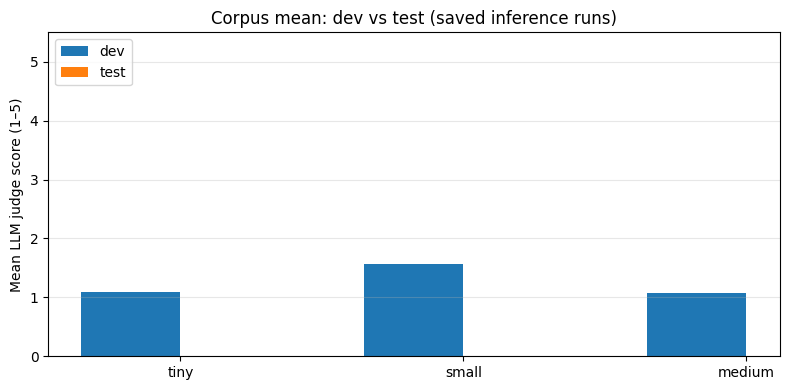

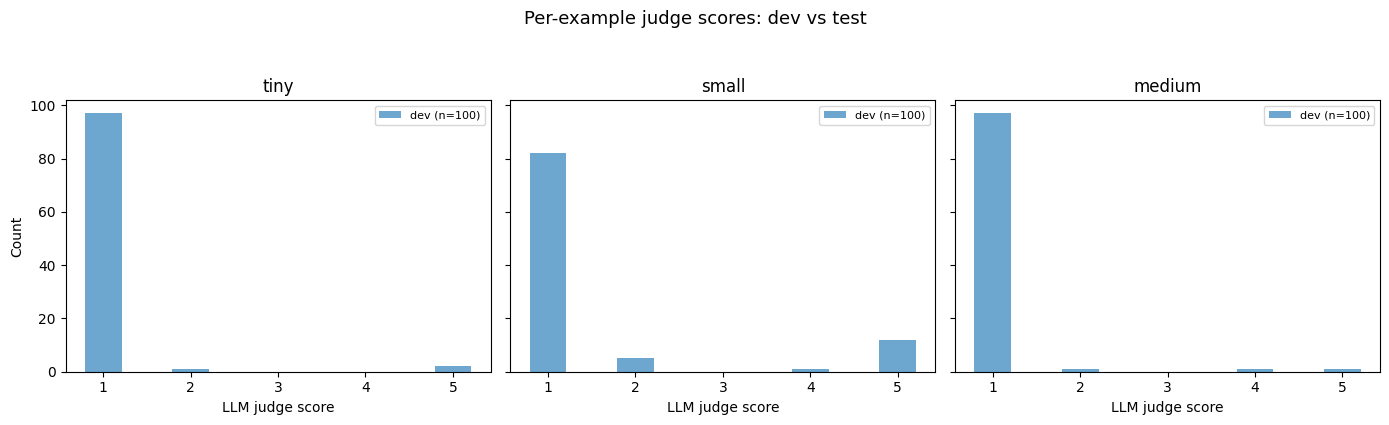

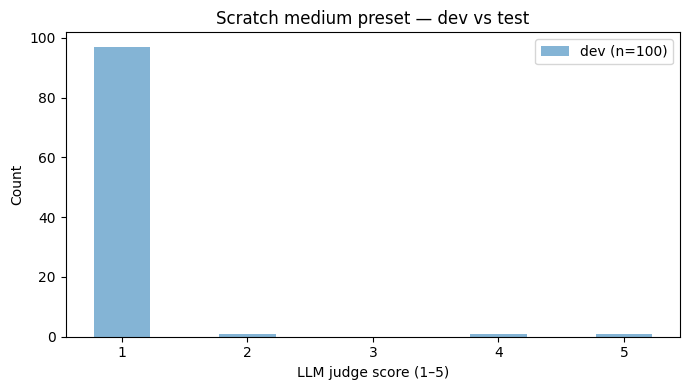

In [ ]:
# Corpus table + figures from ``series`` (run preset cells first).
_rows_html: list[str] = []
for split_tag, _ in SPLIT_SPECS:
    for lab in LABELS_ORDER:
        key = (split_tag, lab)
        json_path = scratch_inference_json_path(REPO_ROOT, split_tag=split_tag, label=lab)
        cache_path = REPO_ROOT / "artifacts" / "llm_judge_runs" / f"{split_tag}_scratch_{lab}.jsonl"
        if key not in series:
            if not json_path.is_file():
                hint = "(no inference JSON)"
            else:
                hint = "(preset cell not run yet)"
            _rows_html.append(
                "<tr>"
                f"<td>{split_tag}</td><td>{lab}</td>"
                "<td>—</td><td>—</td><td>—</td>"
                f"<td style='font-size:12px'><em>{hint}</em></td>"
                "<td>—</td>"
                "</tr>"
            )
            continue

        judge_scores = series[key]
        n = len(judge_scores)
        mu = float(np.mean(judge_scores))
        sd = float(np.std(judge_scores, ddof=0))
        _rows_html.append(
            "<tr>"
            f"<td>{split_tag}</td><td>{lab}</td>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:right'>{mu:.4f}</td>"
            f"<td style='text-align:right'>{sd:.4f}</td>"
            f"<td style='font-size:12px'>{cache_path.name}</td>"
            f"<td style='font-size:12px'>{OLLAMA_MODEL}</td>"
            "</tr>"
        )

_corpus = (
    "<style>"
    ".bm-llm { border-collapse: collapse; font-size: 14px; margin: 0.5em 0 1.2em; } "
    ".bm-llm th, .bm-llm td { border: 1px solid #ccc; padding: 6px 10px; } "
    ".bm-llm th { background: #f4f4f4; text-align: left; } "
    "</style>"
    "<p><strong>LLM judge — corpus summary</strong> (mean / std on **judged** rows — default 100 shared indices per split; em-dash = missing JSON or preset not judged yet)</p>"
    '<table class="bm-llm"><thead><tr>'
    "<th>Split</th><th>Preset</th><th>n</th><th>Mean</th><th>Std</th>"
    "<th>Judge cache</th><th>Ollama model</th>"
    "</tr></thead><tbody>"
    + "".join(_rows_html)
    + "</tbody></table>"
)
display(HTML(_corpus))

# --- Figure 1: mean judge score — dev vs test per preset ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(LABELS_ORDER))
w = 0.35
dev_m = [
    float(np.mean(series[("dev", lab)])) if ("dev", lab) in series else np.nan for lab in LABELS_ORDER
]
test_m = [
    float(np.mean(series[("test", lab)])) if ("test", lab) in series else np.nan for lab in LABELS_ORDER
]
ax.bar(x - w / 2, dev_m, w, label="dev", color="C0")
ax.bar(x + w / 2, test_m, w, label="test", color="C1")
ax.set_xticks(x)
ax.set_xticklabels(LABELS_ORDER)
ax.set_ylabel("Mean LLM judge score (1–5)")
ax.set_ylim(0, 5.5)
ax.set_title("Corpus mean: dev vs test (saved inference runs)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure 2: histograms per preset — dev vs test overlaid ---
bins = [1, 2, 3, 4, 5, 6]
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for axh, lab in zip(axes2, LABELS_ORDER):
    if ("dev", lab) in series:
        axh.hist(
            series[("dev", lab)],
            bins=bins,
            align="left",
            rwidth=0.42,
            alpha=0.65,
            label=f"dev (n={len(series[('dev', lab)])})",
            color="C0",
        )
    if ("test", lab) in series:
        axh.hist(
            series[("test", lab)],
            bins=bins,
            align="left",
            rwidth=0.42,
            alpha=0.65,
            label=f"test (n={len(series[('test', lab)])})",
            color="C1",
        )
    axh.set_title(lab)
    axh.set_xlabel("LLM judge score")
    axh.legend(fontsize=8)
axes2[0].set_ylabel("Count")
fig2.suptitle("Per-example judge scores: dev vs test", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

# --- Figure 3: medium preset — dev vs test ---
fig3, ax3 = plt.subplots(figsize=(7, 4))
lab = "medium"
if ("dev", lab) in series:
    ax3.hist(
        series[("dev", lab)],
        bins=bins,
        align="left",
        rwidth=0.45,
        alpha=0.55,
        label=f"dev (n={len(series[('dev', lab)])})",
        color="C0",
    )
if ("test", lab) in series:
    ax3.hist(
        series[("test", lab)],
        bins=bins,
        align="left",
        rwidth=0.45,
        alpha=0.55,
        label=f"test (n={len(series[('test', lab)])})",
        color="C1",
    )
ax3.set_xlabel("LLM judge score (1–5)")
ax3.set_ylabel("Count")
ax3.set_title("Scratch medium preset — dev vs test")
ax3.legend()
ax3.set_xticks(range(1, 6))
plt.tight_layout()
plt.show()


### Rationale lexicon (offline)

Reads **`artifacts/llm_judge_runs/*.jsonl`** only (each line’s **`rationale`** field). **No** inference runs, **no** Ollama, **no** dependency on **`series`** or the scratch-setup cell — run whenever cached judge logs exist.


In [ ]:
# Offline: scan judge rationale text in existing JSONL caches only.
from __future__ import annotations

import json
import re
from pathlib import Path

from IPython.display import HTML, display


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
JUDGE_RUNS = REPO_ROOT / "artifacts" / "llm_judge_runs"

RATIONALE_LEXICON: tuple[tuple[str, re.Pattern[str]], ...] = (
    ("jumbled", re.compile(r"\bjumbled\b", re.I)),
    ("contradict*", re.compile(r"\bcontradict(?:s|ed|ing|ion|ory)?\b", re.I)),
    ("unrelated", re.compile(r"\bunrelated\b", re.I)),
    ("irrelevant", re.compile(r"\b(?:irrelevant|irrelvant)\b", re.I)),
    ("incoherent", re.compile(r"\bincoherent\b", re.I)),
    ("misleading", re.compile(r"\bmisleading\b", re.I)),
    ("nonsensical", re.compile(r"\bnonsensical\b", re.I)),
)


def rationale_lexicon_counts(cache_path: Path) -> tuple[int, dict[str, int], int]:
    counts = {lbl: 0 for lbl, _ in RATIONALE_LEXICON}
    n_lines = 0
    n_any = 0
    p = Path(cache_path)
    if not p.is_file():
        return 0, counts, 0
    with p.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                continue
            rat = row.get("rationale")
            n_lines += 1
            if not isinstance(rat, str) or not rat.strip():
                continue
            row_hit = False
            for label, pat in RATIONALE_LEXICON:
                n_m = len(pat.findall(rat))
                counts[label] += n_m
                if n_m:
                    row_hit = True
            if row_hit:
                n_any += 1
    return n_lines, counts, n_any


_SCRATCH_NAME = re.compile(r"^(.+)_scratch_(.+)\.jsonl$")

paths = sorted(JUDGE_RUNS.glob("*.jsonl"))
_lex_hdr = "".join(f"<th>{lbl}</th>" for lbl, _ in RATIONALE_LEXICON)

if not paths:
    display(
        HTML(
            "<p><em>No</em> <code>*.jsonl</code> under "
            f"<code>{JUDGE_RUNS.relative_to(REPO_ROOT)}</code>.</p>"
        )
    )
else:
    rows_html: list[str] = []
    for p in paths:
        m = _SCRATCH_NAME.match(p.name)
        split_g = m.group(1) if m else "—"
        preset_g = m.group(2) if m else "—"
        n_lex, lex_cts, n_hit = rationale_lexicon_counts(p)
        lex_cells = "".join(
            f"<td style='text-align:right'>{lex_cts[lbl]}</td>" for lbl, _ in RATIONALE_LEXICON
        )
        rows_html.append(
            "<tr>"
            f"<td style='font-size:12px'>{p.name}</td>"
            f"<td>{split_g}</td><td>{preset_g}</td>"
            f"<td style='text-align:right'>{n_lex}</td>{lex_cells}"
            f"<td style='text-align:right'>{n_hit}</td>"
            "</tr>"
        )

    _tbl = (
        "<style>"
        ".bm-lex { border-collapse: collapse; font-size: 13px; margin: 0.6em 0 1em; } "
        ".bm-lex th, .bm-lex td { border: 1px solid #ccc; padding: 5px 8px; } "
        ".bm-lex th { background: #f4f4f4; text-align: left; } "
        "</style>"
        "<p><strong>Rationale lexicon</strong> — regex hits in <code>rationale</code>; "
        "<em>contradict*</em> covers contradict, contradicts, contradictory, … "
        "<strong>rows w/≥1</strong> = JSONL rows with any hit.</p>"
        '<table class="bm-lex"><thead><tr>'
        "<th>File</th><th>Split</th><th>Preset</th><th>n</th>"
        f"{_lex_hdr}<th>rows w/≥1</th>"
        "</tr></thead><tbody>"
        + "".join(rows_html)
        + "</tbody></table>"
    )
    display(HTML(_tbl))


File,Split,Preset,n,jumbled,contradict*,unrelated,irrelevant,incoherent,misleading,nonsensical,rows w/≥1
dev_scratch_medium.jsonl,dev,medium,100,21,37,51,38,11,28,9,95
dev_scratch_small.jsonl,dev,small,100,2,37,33,11,5,34,1,77
dev_scratch_tiny.jsonl,dev,tiny,100,8,11,75,15,8,12,13,97


### Optional: beam / custom inference folder + paired judge cache

The **Scratch — setup** cell **above** judges **`artifacts/inference_runs/`** and writes **`artifacts/llm_judge_runs/*.jsonl`**.

Use the cells **below** only when **`06`** saved inference under a different folder (e.g. **`inference_runs_beam4`**) and you want judge scores in **`llm_judge_runs_beam4/`** without overwriting greedy caches. Set **`SCRATCH_RUNS_SUBDIR`** in the next cell to match **`06`.**

In [ ]:
# --- Optional: beam / custom inference JSON + paired judge cache (does not change cells above) ---
SCRATCH_RUNS_SUBDIR = "inference_runs_beam4"

from briefme.inference_persist import llm_judge_runs_dir

LLM_JUDGE_CACHE_DIR = llm_judge_runs_dir(REPO_ROOT, inference_artifacts_subdir=SCRATCH_RUNS_SUBDIR)
print("[optional beam] judge cache:", LLM_JUDGE_CACHE_DIR.relative_to(REPO_ROOT), flush=True)

import time
import zlib

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

from briefme.inference_persist import load_inference_json, scratch_inference_json_path

LABELS_ORDER = ("tiny", "small", "medium")
SPLIT_SPECS = (
    ("dev", SPLIT_DEV),
    ("test", SPLIT_TEST),
)

# Same row indices for tiny/small/medium within each split. Set **0** or **None** for full JSON.
JUDGE_SAMPLE_K = 100
JUDGE_SAMPLE_SEED = 42

# --- Fixed judge rows (greedy vs beam consistency) ---
# When True, rows judged are exactly these indices (same every run / kernel). When False, uses the legacy
# session-locked RNG sample (SCRATCH_JUDGE_ROW_IDXS_BEAM) so results match older notebooks.
# Lists below: K=100, seed=42, anchor_n=2319 for BriefMe arg_summ (matches min preds length across presets).
USE_HARDCODED_JUDGE_ROWS = True
HARDCODED_JUDGE_ROW_IDXS: dict[str, tuple[int, ...]] = {
    "dev": (3, 24, 42, 77, 87, 113, 130, 147, 203, 225, 241, 253, 280, 339, 342, 357, 367, 394, 409, 422, 425, 454, 479, 492, 496, 534, 560, 574, 615, 630, 686, 701, 707, 714, 741, 742, 748, 755, 759, 780, 781, 817, 832, 840, 847, 897, 947, 949, 964, 965, 966, 990, 1009, 1054, 1100, 1145, 1161, 1169, 1178, 1184, 1225, 1228, 1258, 1285, 1299, 1338, 1356, 1375, 1393, 1409, 1469, 1472, 1480, 1484, 1516, 1526, 1555, 1568, 1575, 1583, 1598, 1641, 1663, 1729, 1738, 1771, 1812, 1821, 1865, 1927, 1958, 1979, 2090, 2102, 2128, 2169, 2233, 2270, 2293, 2300),
    # ``test`` uses the same anchor_n and K as dev but crc32(subseed) for split_tag "test".
    "test": (7, 23, 53, 75, 94, 115, 158, 173, 196, 217, 280, 292, 295, 317, 323, 358, 376, 504, 518, 545, 546, 549, 597, 606, 609, 628, 632, 659, 663, 690, 711, 748, 798, 815, 829, 859, 860, 892, 896, 919, 948, 993, 1025, 1028, 1073, 1096, 1100, 1107, 1167, 1174, 1190, 1205, 1253, 1283, 1290, 1317, 1332, 1377, 1391, 1392, 1404, 1474, 1507, 1538, 1539, 1553, 1590, 1599, 1607, 1667, 1676, 1694, 1720, 1784, 1787, 1792, 1796, 1814, 1827, 1845, 1859, 1890, 1903, 1908, 1920, 1943, 1949, 1963, 1975, 2001, 2056, 2057, 2127, 2145, 2208, 2241, 2264, 2265, 2292, 2306),
}

print(
    f"[judge config] JUDGE_SAMPLE_K={JUDGE_SAMPLE_K!r} — "
    "shared row indices across presets per split; "
    "0 or None = full corpus.  Each Ollama judge call is logged (row, score, wall_s, cache_hit).",
    flush=True,
)
print(f"[judge config] USE_HARDCODED_JUDGE_ROWS={USE_HARDCODED_JUDGE_ROWS!r}", flush=True)

series_beam: dict[tuple[str, str], list[int]] = {}

# Locked once per kernel session per split_tag — same rows for tiny / small / medium (legacy mode only)
SCRATCH_JUDGE_ROW_IDXS_BEAM: dict[str, np.ndarray] = {}


def reset_judge_row_indices_beam() -> None:
    """Clear SCRATCH_JUDGE_ROW_IDXS after changing JUDGE_SAMPLE_SEED / JUDGE_SAMPLE_K (legacy sampling)."""
    SCRATCH_JUDGE_ROW_IDXS_BEAM.clear()


def _json_row_count_beam(split_tag: str, label: str) -> int | None:
    p = scratch_inference_json_path(
        REPO_ROOT, split_tag=split_tag, label=label, artifacts_subdir=SCRATCH_RUNS_SUBDIR
    )
    if not p.is_file():
        return None
    data = load_inference_json(p)
    return len(data["preds"])


def _anchor_n_for_split_beam(split_tag: str) -> int | None:
    """Minimum preds length across preset JSON files that exist for this split."""
    ns = [_json_row_count_beam(split_tag, lab) for lab in LABELS_ORDER]
    ns = [n for n in ns if n is not None]
    return min(ns) if ns else None


def judge_scratch_preset_beam(label: str) -> None:
    """Judge dev + test for one preset; updates ``series``."""
    if label not in LABELS_ORDER:
        raise ValueError(f"label must be one of {LABELS_ORDER}")
    for split_tag, _ in SPLIT_SPECS:
        json_path = scratch_inference_json_path(
            REPO_ROOT, split_tag=split_tag, label=label, artifacts_subdir=SCRATCH_RUNS_SUBDIR
        )
        cache_path = LLM_JUDGE_CACHE_DIR / f"{split_tag}_scratch_{label}.jsonl"

        if not json_path.is_file():
            series_beam.pop((split_tag, label), None)
            print(f"[skip] {split_tag} · {label}: no inference file ({json_path.name})")
            continue

        data = load_inference_json(json_path)
        preds = data["preds"]
        refs = data["refs"]
        sources = data["sources"]
        lp, lr, ls = len(preds), len(refs), len(sources)
        if lp != lr or lp != ls:
            series_beam.pop((split_tag, label), None)
            print(f"[skip] {json_path.name}: length mismatch preds={lp} refs={lr} sources={ls}")
            continue

        n_json = lp

        if data.get("split_tag") != split_tag:
            print(f"[warn] {json_path.name}: split_tag={data.get('split_tag')} != {split_tag}")

        if JUDGE_SAMPLE_K is not None and int(JUDGE_SAMPLE_K) > 0:
            if USE_HARDCODED_JUDGE_ROWS and split_tag in HARDCODED_JUDGE_ROW_IDXS:
                fixed = np.array(HARDCODED_JUDGE_ROW_IDXS[split_tag], dtype=int)
                idxs = fixed[fixed < n_json]
                if len(idxs) < len(fixed):
                    print(
                        f"[warn] {split_tag} · {label}: hardcoded judge rows clipped to rows_in_json={n_json} "
                        f"({len(idxs)}/{len(fixed)} kept). Regenerate HARDCODED_JUDGE_ROW_IDXS if intentional.",
                        flush=True,
                    )
                if len(idxs) == 0:
                    series_beam.pop((split_tag, label), None)
                    print(
                        f"[skip] {split_tag} · {label}: no hardcoded indices in range for rows_in_json={n_json}",
                        flush=True,
                    )
                    continue
                tag = f"HARDCODED_JUDGE_ROW_IDXS  n_judged={len(idxs)} / rows_in_json={n_json}"
            else:
                if split_tag not in SCRATCH_JUDGE_ROW_IDXS_BEAM:
                    anchor = _anchor_n_for_split_beam(split_tag)
                    if anchor is None:
                        anchor = n_json
                    k_eff = min(int(JUDGE_SAMPLE_K), anchor)
                    subseed = zlib.crc32(f"{JUDGE_SAMPLE_SEED}:{split_tag}".encode()) % (2**32)
                    rng = np.random.default_rng(subseed)
                    SCRATCH_JUDGE_ROW_IDXS_BEAM[split_tag] = np.sort(rng.permutation(anchor)[:k_eff])
                    print(
                        f"[judge] {split_tag}: SCRATCH_JUDGE_ROW_IDXS locked "
                        f"(anchor_n={anchor}) → {SCRATCH_JUDGE_ROW_IDXS_BEAM[split_tag].tolist()}",
                        flush=True,
                    )

                idxs = SCRATCH_JUDGE_ROW_IDXS_BEAM[split_tag]
                idxs = idxs[idxs < n_json]
                if len(idxs) == 0:
                    series_beam.pop((split_tag, label), None)
                    print(
                        f"[skip] {split_tag} · {label}: no indices in range for rows_in_json={n_json}",
                        flush=True,
                    )
                    continue
                if len(idxs) < len(SCRATCH_JUDGE_ROW_IDXS_BEAM[split_tag]):
                    print(
                        f"[warn] {split_tag} · {label}: using {len(idxs)}/"
                        f"{len(SCRATCH_JUDGE_ROW_IDXS_BEAM[split_tag])} locked rows (rows_in_json={n_json}).",
                        flush=True,
                    )
                tag = f"SCRATCH_JUDGE_ROW_IDXS  n_judged={len(idxs)} / rows_in_json={n_json}"
        else:
            idxs = np.arange(n_json, dtype=int)
            tag = f"full corpus {n_json} rows"

        print(f"[judge] {split_tag} · {label}  start  {tag}  → {cache_path.name}", flush=True)

        judge_scores: list[int] = []
        cache_hits_run = 0
        wall_times: list[float] = []
        ollama_times: list[float] = []

        for step_j, i in enumerate(idxs, start=1):
            i = int(i)
            t0 = time.perf_counter()
            out = score_heading(
                sources[i],
                preds[i],
                reference_optional=refs[i],
                host=OLLAMA_HOST,
                model=OLLAMA_MODEL,
                cache_path=cache_path,
            )
            dt = time.perf_counter() - t0
            wall_times.append(dt)
            hit = bool(out.get("cache_hit"))
            if hit:
                cache_hits_run += 1
            else:
                ollama_times.append(dt)

            judge_scores.append(int(out["score"]))

            print(
                f"[judge] {split_tag} · {label}  {step_j}/{len(idxs)}  row={i}  "
                f"score={int(out['score'])}  wall_s={dt:.3f}  cache_hit={hit}",
                flush=True,
            )

        series_beam[(split_tag, label)] = judge_scores
        mu = float(np.mean(judge_scores))
        sd = float(np.std(judge_scores, ddof=0))
        mean_w = float(np.mean(wall_times)) if wall_times else 0.0
        om = float(np.mean(ollama_times)) if ollama_times else float("nan")
        om_ex = ""
        if not np.isnan(om):
            om_ex = f"  ollama_mean_s={om:.3f} (n={len(ollama_times)})"
        print(
            f"[done] {split_tag} · {label}  judged={len(judge_scores)}  rows_in_json={n_json}  "
            f"mean={mu:.4f}  std={sd:.4f}  mean_wall_s={mean_w:.3f}{om_ex}  → {cache_path.name}"
        )


### Beam — Tiny / Small / Medium (optional)

Same as above, but calls `judge_scratch_preset_beam`.

In [ ]:
judge_scratch_preset_beam("tiny")


In [ ]:
judge_scratch_preset_beam("small")


In [ ]:
judge_scratch_preset_beam("medium")


### Report — beam / custom subdir (optional)

Run after optional beam preset cells; uses **`series_beam`**.

In [ ]:
# Corpus table + figures from ``series_beam`` (run preset cells first).
_rows_html: list[str] = []
for split_tag, _ in SPLIT_SPECS:
    for lab in LABELS_ORDER:
        key = (split_tag, lab)
        json_path = scratch_inference_json_path(
            REPO_ROOT, split_tag=split_tag, label=lab, artifacts_subdir=SCRATCH_RUNS_SUBDIR
        )
        cache_path = LLM_JUDGE_CACHE_DIR / f"{split_tag}_scratch_{lab}.jsonl"
        if key not in series_beam:
            if not json_path.is_file():
                hint = "(no inference JSON)"
            else:
                hint = "(preset cell not run yet)"
            _rows_html.append(
                "<tr>"
                f"<td>{split_tag}</td><td>{lab}</td>"
                "<td>—</td><td>—</td><td>—</td>"
                f"<td style='font-size:12px'><em>{hint}</em></td>"
                "<td>—</td>"
                "</tr>"
            )
            continue

        judge_scores = series_beam[key]
        n = len(judge_scores)
        mu = float(np.mean(judge_scores))
        sd = float(np.std(judge_scores, ddof=0))
        _rows_html.append(
            "<tr>"
            f"<td>{split_tag}</td><td>{lab}</td>"
            f"<td style='text-align:right'>{n}</td>"
            f"<td style='text-align:right'>{mu:.4f}</td>"
            f"<td style='text-align:right'>{sd:.4f}</td>"
            f"<td style='font-size:12px'>{cache_path.name}</td>"
            f"<td style='font-size:12px'>{OLLAMA_MODEL}</td>"
            "</tr>"
        )

_corpus = (
    "<style>"
    ".bm-llm { border-collapse: collapse; font-size: 14px; margin: 0.5em 0 1.2em; } "
    ".bm-llm th, .bm-llm td { border: 1px solid #ccc; padding: 6px 10px; } "
    ".bm-llm th { background: #f4f4f4; text-align: left; } "
    "</style>"
    "<p><strong>LLM judge — corpus summary (optional beam / custom subdir)</strong> (mean / std on **judged** rows — default 100 shared indices per split; em-dash = missing JSON or preset not judged yet)</p>"
    '<table class="bm-llm"><thead><tr>'
    "<th>Split</th><th>Preset</th><th>n</th><th>Mean</th><th>Std</th>"
    "<th>Judge cache</th><th>Ollama model</th>"
    "</tr></thead><tbody>"
    + "".join(_rows_html)
    + "</tbody></table>"
)
display(HTML(_corpus))

# --- Figure 1: mean judge score — dev vs test per preset ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(LABELS_ORDER))
w = 0.35
dev_m = [
    float(np.mean(series_beam[("dev", lab)])) if ("dev", lab) in series_beam else np.nan for lab in LABELS_ORDER
]
test_m = [
    float(np.mean(series_beam[("test", lab)])) if ("test", lab) in series_beam else np.nan for lab in LABELS_ORDER
]
ax.bar(x - w / 2, dev_m, w, label="dev", color="C0")
ax.bar(x + w / 2, test_m, w, label="test", color="C1")
ax.set_xticks(x)
ax.set_xticklabels(LABELS_ORDER)
ax.set_ylabel("Mean LLM judge score (1–5)")
ax.set_ylim(0, 5.5)
ax.set_title("Corpus mean: dev vs test (saved inference runs)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure 2: histograms per preset — dev vs test overlaid ---
bins = [1, 2, 3, 4, 5, 6]
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for axh, lab in zip(axes2, LABELS_ORDER):
    if ("dev", lab) in series_beam:
        axh.hist(
            series_beam[("dev", lab)],
            bins=bins,
            align="left",
            rwidth=0.42,
            alpha=0.65,
            label=f"dev (n={len(series_beam[('dev', lab)])})",
            color="C0",
        )
    if ("test", lab) in series_beam:
        axh.hist(
            series_beam[("test", lab)],
            bins=bins,
            align="left",
            rwidth=0.42,
            alpha=0.65,
            label=f"test (n={len(series_beam[('test', lab)])})",
            color="C1",
        )
    axh.set_title(lab)
    axh.set_xlabel("LLM judge score")
    axh.legend(fontsize=8)
axes2[0].set_ylabel("Count")
fig2.suptitle("Per-example judge scores: dev vs test", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

# --- Figure 3: medium preset — dev vs test ---
fig3, ax3 = plt.subplots(figsize=(7, 4))
lab = "medium"
if ("dev", lab) in series_beam:
    ax3.hist(
        series_beam[("dev", lab)],
        bins=bins,
        align="left",
        rwidth=0.45,
        alpha=0.55,
        label=f"dev (n={len(series_beam[('dev', lab)])})",
        color="C0",
    )
if ("test", lab) in series_beam:
    ax3.hist(
        series_beam[("test", lab)],
        bins=bins,
        align="left",
        rwidth=0.45,
        alpha=0.55,
        label=f"test (n={len(series_beam[('test', lab)])})",
        color="C1",
    )
ax3.set_xlabel("LLM judge score (1–5)")
ax3.set_ylabel("Count")
ax3.set_title("Scratch medium preset — dev vs test")
ax3.legend()
ax3.set_xticks(range(1, 6))
plt.tight_layout()
plt.show()


### Optional: rationale lexicon across all judge caches

The offline cell **above** scans only **`artifacts/llm_judge_runs/*.jsonl`**. Run the next cell to include **`artifacts/llm_judge_runs*/`** (greedy + beam).

In [ ]:
# Optional: scan every ``artifacts/llm_judge_runs*/`` dir (add-on; keeps prior cell unchanged).
from __future__ import annotations

import json
import re
from pathlib import Path

from IPython.display import HTML, display


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
_ART = REPO_ROOT / "artifacts"
_LEX_DIRS = sorted(d for d in _ART.glob("llm_judge_runs*") if d.is_dir())
paths = sorted(p for d in _LEX_DIRS for p in d.glob("*.jsonl"))

RATIONALE_LEXICON: tuple[tuple[str, re.Pattern[str]], ...] = (
    ("jumbled", re.compile(r"\bjumbled\b", re.I)),
    ("contradict*", re.compile(r"\bcontradict(?:s|ed|ing|ion|ory)?\b", re.I)),
    ("unrelated", re.compile(r"\bunrelated\b", re.I)),
    ("irrelevant", re.compile(r"\b(?:irrelevant|irrelvant)\b", re.I)),
    ("incoherent", re.compile(r"\bincoherent\b", re.I)),
    ("misleading", re.compile(r"\bmisleading\b", re.I)),
    ("nonsensical", re.compile(r"\bnonsensical\b", re.I)),
)


def rationale_lexicon_counts(cache_path: Path) -> tuple[int, dict[str, int], int]:
    counts = {lbl: 0 for lbl, _ in RATIONALE_LEXICON}
    n_lines = 0
    n_any = 0
    p = Path(cache_path)
    if not p.is_file():
        return 0, counts, 0
    with p.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                continue
            rat = row.get("rationale")
            n_lines += 1
            if not isinstance(rat, str) or not rat.strip():
                continue
            row_hit = False
            for label, pat in RATIONALE_LEXICON:
                n_m = len(pat.findall(rat))
                counts[label] += n_m
                if n_m:
                    row_hit = True
            if row_hit:
                n_any += 1
    return n_lines, counts, n_any


_SCRATCH_NAME = re.compile(r"^(.+)_scratch_(.+)\.jsonl$")

_lex_hdr = "".join(f"<th>{lbl}</th>" for lbl, _ in RATIONALE_LEXICON)

if not paths:
    hint = (
        "no `artifacts/llm_judge_runs*` dirs"
        if not _LEX_DIRS
        else "no `*.jsonl` in " + ", ".join(f"`{d.relative_to(REPO_ROOT)}`" for d in _LEX_DIRS)
    )
    display(HTML(f"<p><em>No</em> judge JSONL files found ({hint}).</p>"))
else:
    rows_html: list[str] = []
    for p in paths:
        m = _SCRATCH_NAME.match(p.name)
        split_g = m.group(1) if m else "—"
        preset_g = m.group(2) if m else "—"
        n_lex, lex_cts, n_hit = rationale_lexicon_counts(p)
        lex_cells = "".join(
            f"<td style='text-align:right'>{lex_cts[lbl]}</td>" for lbl, _ in RATIONALE_LEXICON
        )
        rows_html.append(
            "<tr>"
            f"<td style='font-size:12px'>{p.relative_to(REPO_ROOT)}</td>"
            f"<td>{split_g}</td><td>{preset_g}</td>"
            f"<td style='text-align:right'>{n_lex}</td>{lex_cells}"
            f"<td style='text-align:right'>{n_hit}</td>"
            "</tr>"
        )

    _tbl = (
        "<style>"
        ".bm-lex { border-collapse: collapse; font-size: 13px; margin: 0.6em 0 1em; } "
        ".bm-lex th, .bm-lex td { border: 1px solid #ccc; padding: 5px 8px; } "
        ".bm-lex th { background: #f4f4f4; text-align: left; } "
        "</style>"
        "<p><strong>Rationale lexicon (all <code>llm_judge_runs*</code> dirs)</strong> — regex hits in <code>rationale</code>; "
        "<em>contradict*</em> covers contradict, contradicts, contradictory, … "
        "<strong>rows w/≥1</strong> = JSONL rows with any hit.</p>"
        '<table class="bm-lex"><thead><tr>'
        "<th>File</th><th>Split</th><th>Preset</th><th>n</th>"
        f"{_lex_hdr}<th>rows w/≥1</th>"
        "</tr></thead><tbody>"
        + "".join(rows_html)
        + "</tbody></table>"
    )
    display(HTML(_tbl))
